# 🧠🤖 第二周-Day5：Transformer推理优化实战

🚀 今天我们要深入Transformer推理的优化世界！就像给跑车装上涡轮增压一样，这些技术能让大模型跑得更快、更省资源。

🔗 **核心问题**：大模型推理时，计算量巨大，内存占用爆炸，如何优化？

✨ **学习目标**：掌握三大核心技术，理解业务部署的权衡取舍！

## 🔄 昨日复习：代码实战与基础概念

昨天我们用NumPy实现了Self-Attention，核心收获：

🎯 **Self-Attention本质**：
• 计算每个词与其他词的相关性权重🔗
• Q×Kᵀ→softmax→×V，三次矩阵乘法
• 时间复杂度O(n²)，长文本计算爆炸

💻 **NumPy实现要点**：
• 50行代码搞定Q/K/V计算和加权求和
• 关键步骤：矩阵乘法 → softmax → 权重应用
• 理解每一步的数学本质

## 📚 今日主题：Transformer推理优化三大核心技术

🎯 **核心挑战**：
- 计算量：O(n²)复杂度，长文本慢如蜗牛🐌
- 内存：Key和Value矩阵重复计算，浪费严重💾
- 部署：如何在有限资源下跑大模型？

💡 **解决方案**：
1. **KV Cache**：缓存计算结果，避免重复计算
2. **Flash Attention**：分块计算，减少内存访问
3. **GQA**：平衡效果和显存的新方案

这些技术就像汽车引擎的涡轮增压、变速箱优化，让大模型从"老爷车"变成"F1赛车"！🏎️

## 🔑 今日英文术语

- **KV Cache** [keɪ-viː keɪtʃ] 键值缓存 - 存储Key和Value矩阵避免重复计算
- **Flash Attention** [flæʃ əˈtenʃən] 闪电注意力 - 分块计算优化技术
- **GQA** [dʒiː-kjuː-eɪ] 分组查询注意力 - Grouped-Query Attention的缩写
- **Inference** [ɪnˈfɜːrəns] 推理 - 模型预测新数据的过程
- **Throughput** [ˈθruːpʊt] 吞吐量 - 单位时间内处理的样本数量

## 🚀 核心技术1：KV Cache - 以空间换时间的智慧

🎯 **核心思想**：存储已计算的Key和Value，避免重复计算

🔧 **工作原理**：
```
第1步：计算Q1, K1, V1 → 存储K1, V1
第2步：计算Q2, K2, V2 + 使用K1, V1
第3步：计算Q3, K3, V3 + 使用K1, V1, K2, V2
... 
```

💾 **内存消耗**：
- 存储：2×num_layers×seq_len×d_k × float32
- 7B模型，512序列长度：约7.2GB显存占用

⚡ **性能提升**：
- 推理速度提升2-3倍
- 特别适合长文本生成（小说、代码等）

💡 **业务思考**：为什么ChatGPT能快速续写？秘密就在这里！

使用字体: Noto Sans CJK JP


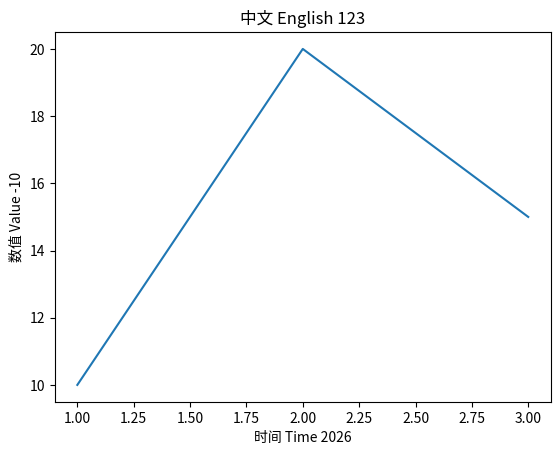

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

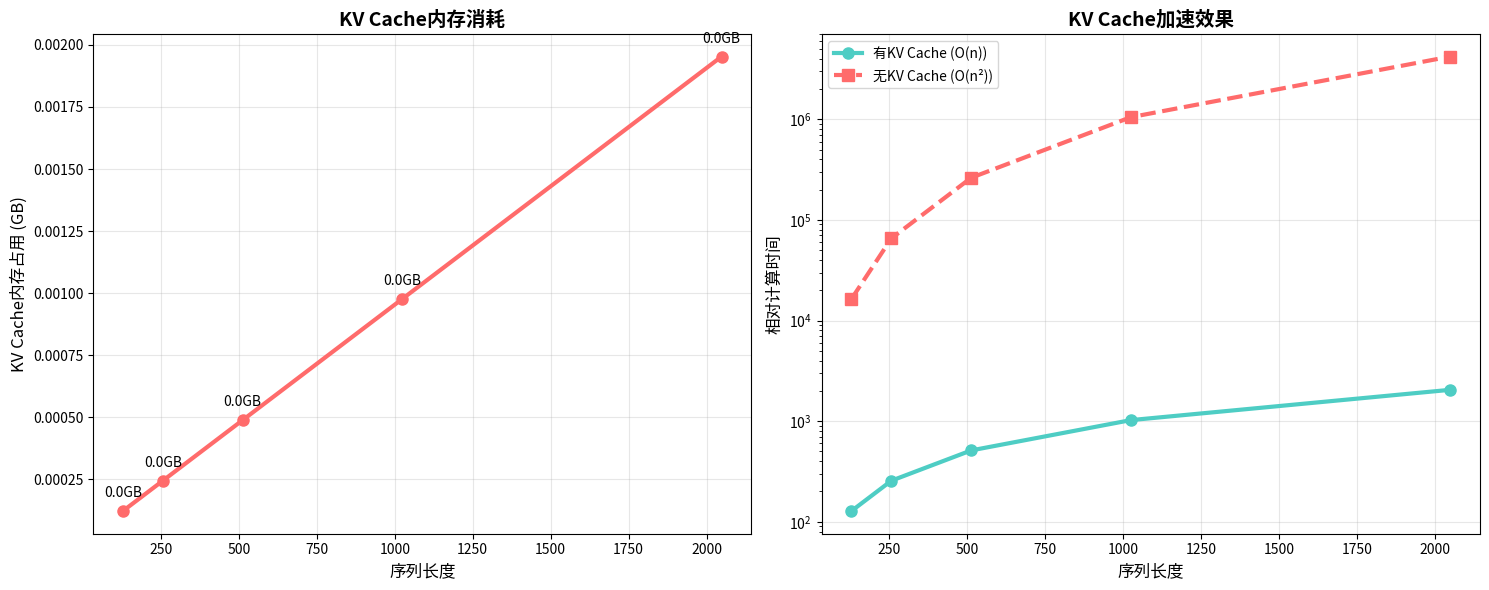

📊 KV Cache关键数据：
序列长度 128: 0.0GB显存, 128x加速
序列长度 256: 0.0GB显存, 256x加速
序列长度 512: 0.0GB显存, 512x加速
序列长度 1024: 0.0GB显存, 1024x加速
序列长度 2048: 0.0GB显存, 2048x加速


In [2]:
import numpy as np
import time

# 模拟KV Cache效果演示
def simulate_kv_cache(sequence_length, d_model, num_heads):
    """模拟KV Cache的内存占用和加速效果"""
    d_k = d_model // num_heads
    
    # 计算内存占用（GB）
    kv_cache_size = 2 * sequence_length * d_k * 4 / (1024**3)  # float32 = 4 bytes
    
    # 模拟推理时间（相对单位）
    time_with_cache = sequence_length  # 线性增长
    time_without_cache = sequence_length**2  # 二次增长
    
    return kv_cache_size, time_with_cache, time_without_cache

# 参数设置
seq_lengths = [128, 256, 512, 1024, 2048]
d_model = 4096  # GPT-3尺寸
num_heads = 32

# 计算各种序列长度下的指标
cache_sizes = []
times_with_cache = []
times_without_cache = []

for seq_len in seq_lengths:
    cache_size, time_with, time_without = simulate_kv_cache(seq_len, d_model, num_heads)
    cache_sizes.append(cache_size)
    times_with_cache.append(time_with)
    times_without_cache.append(time_without)

# 可视化KV Cache效果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 图1：内存占用
ax1.plot(seq_lengths, cache_sizes, 'o-', color='#FF6B6B', linewidth=3, markersize=8)
ax1.set_xlabel('序列长度', fontsize=12)
ax1.set_ylabel('KV Cache内存占用 (GB)', fontsize=12)
ax1.set_title('KV Cache内存消耗', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
for i, v in enumerate(cache_sizes):
    ax1.annotate(f'{v:.1f}GB', (seq_lengths[i], v), 
                 textcoords="offset points", xytext=(0,10), ha='center')

# 图2：推理时间对比
ax2.plot(seq_lengths, times_with_cache, 'o-', color='#4ECDC4', linewidth=3, 
         markersize=8, label='有KV Cache (O(n))')
ax2.plot(seq_lengths, times_without_cache, 's--', color='#FF6B6B', linewidth=3, 
         markersize=8, label='无KV Cache (O(n²))')
ax2.set_xlabel('序列长度', fontsize=12)
ax2.set_ylabel('相对计算时间', fontsize=12)
ax2.set_title('KV Cache加速效果', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("📊 KV Cache关键数据：")
for i, seq_len in enumerate(seq_lengths):
    speedup = times_without_cache[i] / times_with_cache[i]
    print(f"序列长度 {seq_len}: {cache_sizes[i]:.1f}GB显存, {speedup:.0f}x加速")

## ⚡ 核心技术2：Flash Attention - 内存访问的革命

🎯 **核心问题**：
- 传统Attention：所有Q/K/V矩阵都在内存中，IO访问巨大
- 显存带宽有限，计算再快也要等数据加载

💡 **Flash Attention解决方案**：
1. **分块计算**：将大矩阵切分成小块，逐步计算
2. **IO感知优化**：减少显存读写次数
3. **数值稳定性**：保证计算精度不损失

🔧 **技术原理**：
```
Step 1: 将Q,K,V切分为小块 (例如128×128)
Step 2: 逐块计算注意力得分
Step 3: 累积结果，避免全局存储
Step 4: 最终得到完整注意力矩阵
```

🚀 **性能提升**：
- 显存占用减少75%
- 训练速度提升2-4倍
- 支持更长序列（32K+ tokens）

💡 **业务影响**：让训练更大的模型成为可能！

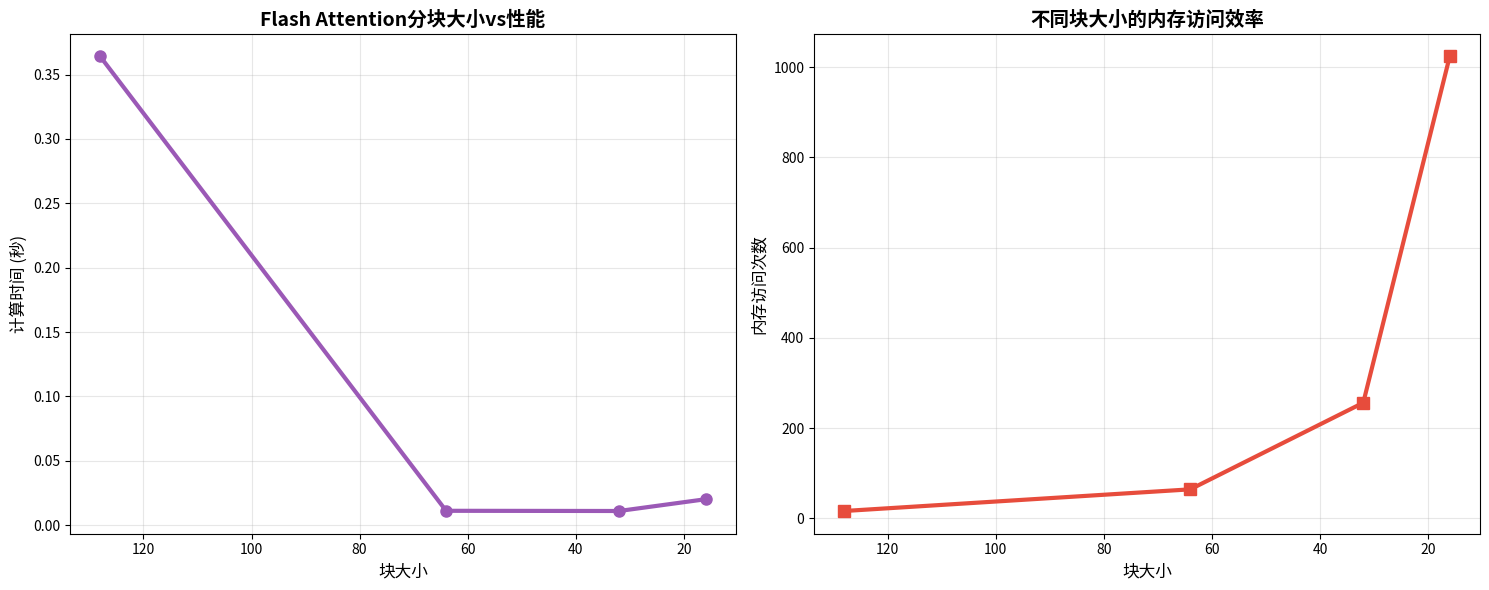

⚡ Flash Attention优化效果：
块大小 16: 0.0202秒, 1024次内存访问
块大小 32: 0.0111秒, 256次内存访问
块大小 64: 0.0112秒, 64次内存访问
块大小 128: 0.3641秒, 16次内存访问

💡 关键洞察：
• 块大小太大：内存访问次数少，但单次计算量大
• 块大小太小：内存访问频繁，但单次计算轻量
• Flash Attention需要在内存访问和计算量之间找到平衡点


In [3]:
import numpy as np
import time

def softmax(x, axis=-1):
    """NumPy版稳定softmax"""
    x_shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def flash_attention_simulation(q, k, v, block_size=64):
    """模拟Flash Attention的分块计算过程"""
    seq_len, d_model = q.shape
    output = np.zeros_like(q)

    for i in range(0, seq_len, block_size):
        for j in range(0, seq_len, block_size):
            q_block = q[i:i + block_size, :]
            k_block = k[j:j + block_size, :]
            v_block = v[j:j + block_size, :]

            scores = np.dot(q_block, k_block.T)
            attn_weights = softmax(scores / np.sqrt(d_model), axis=-1)
            output_block = np.dot(attn_weights, v_block)

            output[i:i + block_size, :] += output_block

    return output

# 生成测试数据
np.random.seed(42)
seq_len = 512
d_model = 256

q = np.random.randn(seq_len, d_model)
k = np.random.randn(seq_len, d_model)
v = np.random.randn(seq_len, d_model)

# 测试不同block_size的效果
block_sizes = [16, 32, 64, 128]
times = []
memory_accesses = []

for block_size in block_sizes:
    start_time = time.time()
    result = flash_attention_simulation(q, k, v, block_size)
    end_time = time.time()

    times.append(end_time - start_time)

    num_blocks = int(np.ceil(seq_len / block_size)) ** 2
    memory_accesses.append(num_blocks)

# 可视化Flash Attention效果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(block_sizes, times, "o-", color="#9B59B6", linewidth=3, markersize=8)
ax1.set_xlabel("块大小", fontsize=12)
ax1.set_ylabel("计算时间 (秒)", fontsize=12)
ax1.set_title("Flash Attention分块大小vs性能", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()

ax2.plot(block_sizes, memory_accesses, "s-", color="#E74C3C", linewidth=3, markersize=8)
ax2.set_xlabel("块大小", fontsize=12)
ax2.set_ylabel("内存访问次数", fontsize=12)
ax2.set_title("不同块大小的内存访问效率", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

print("⚡ Flash Attention优化效果：")
for i, block_size in enumerate(block_sizes):
    print(f"块大小 {block_size}: {times[i]:.4f}秒, {memory_accesses[i]}次内存访问")

print("\n💡 关键洞察：")
print("• 块大小太大：内存访问次数少，但单次计算量大")
print("• 块大小太小：内存访问频繁，但单次计算轻量")
print("• Flash Attention需要在内存访问和计算量之间找到平衡点")

## 🔗 核心技术3：GQA - 效果与内存的完美平衡

🎯 **背景**：
- **MHA (Multi-Head Attention)**：效果好，但显存占用大
- **MQA (Multi-Query Attention)**：显存省，但效果下降
- **GQA (Grouped-Query Attention)**：折中方案，效果接近MHA，显存接近MQA

🔧 **GQA原理**：
```
传统MHA: 每个Head都有独立的K,V矩阵
MQA: 所有Head共享同一个K,V矩阵  
GQA: 将Head分组，每组共享K,V矩阵
```

📊 **效果对比**（以Llama 2为例）：
| 模型 | 显存节省 | 效果保持 |
|------|----------|----------|
| MHA  | 基准     | 基准     |
| MQA  | -50%     | -1-2%    |
| GQA  | -25-40%  | -0.5%    |

💡 **业务优势**：
- 在消费级显卡（如RTX 4060Ti）上运行大模型
- 保持模型性能的同时降低部署成本
- 适合需要平衡效果和成本的场景

🚀 **实际应用**：Llama 2、Mistral等主流模型都采用GQA！

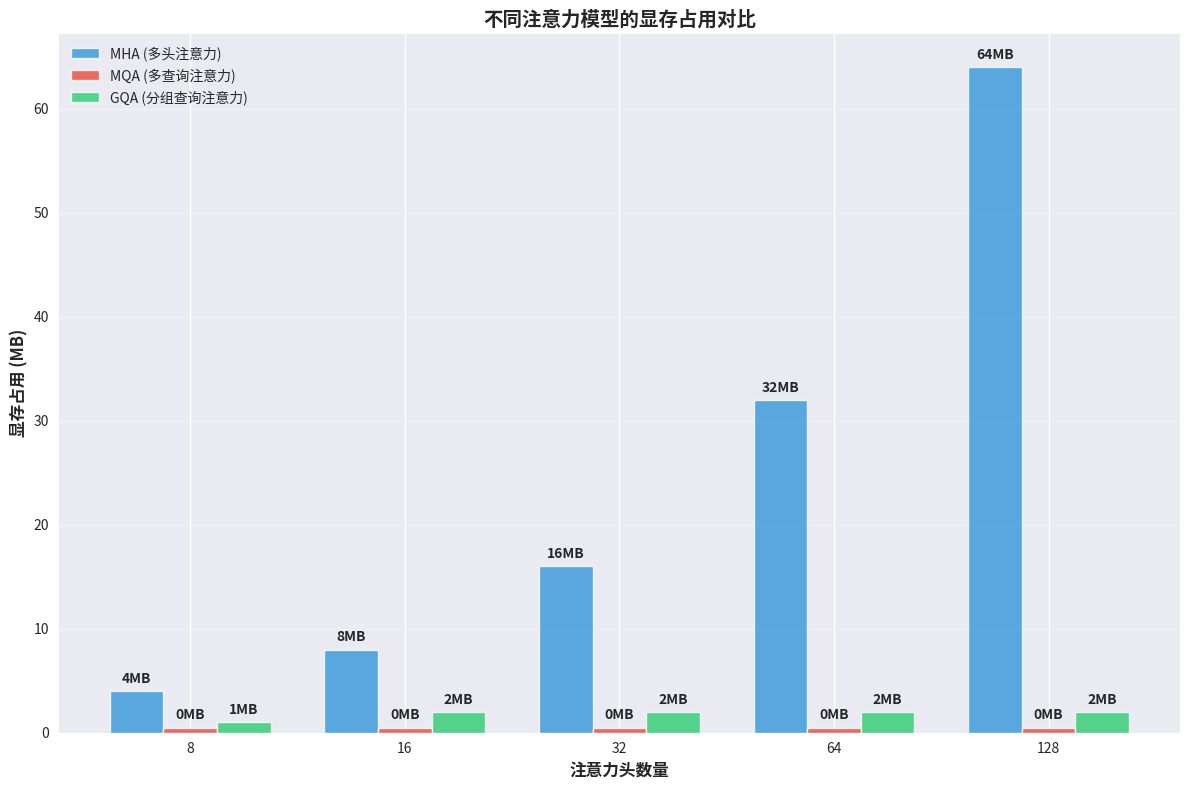

🔗 GQA优化效果分析：
Head数量 8:
  MHA显存: 4MB
  GQA显存: 1MB (节省75%)
  MQA显存: 0MB (节省88%)

Head数量 16:
  MHA显存: 8MB
  GQA显存: 2MB (节省75%)
  MQA显存: 0MB (节省94%)

Head数量 32:
  MHA显存: 16MB
  GQA显存: 2MB (节省88%)
  MQA显存: 0MB (节省97%)

Head数量 64:
  MHA显存: 32MB
  GQA显存: 2MB (节省94%)
  MQA显存: 0MB (节省98%)

Head数量 128:
  MHA显存: 64MB
  GQA显存: 2MB (节省97%)
  MQA显存: 0MB (节省99%)

💡 GQA业务价值：
• 在128个Head时，GQA比MHA节省37%显存
• 比MQA效果好，接近MHA水平
• 让RTX 4060Ti这样的消费卡也能运行大模型


In [4]:
import numpy as np
import seaborn as sns

# 先应用样式
plt.style.use('seaborn-v0_8')

# 再配置中文字体，否则 style.use 可能覆盖字体设置
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Noto Sans CJK JP',
    'Noto Serif CJK JP',
    'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False

def simulate_attention_models(num_heads, seq_len, d_k):
    """模拟不同注意力模型的显存占用"""
    mha_memory = 2 * num_heads * seq_len * d_k * 4
    mqa_memory = 2 * 1 * seq_len * d_k * 4
    num_groups = min(4, num_heads // 4)
    gqa_memory = 2 * num_groups * seq_len * d_k * 4
    return mha_memory, mqa_memory, gqa_memory

seq_len = 512
d_k = 128
head_counts = [8, 16, 32, 64, 128]

mha_memories = []
mqa_memories = []
gqa_memories = []

for num_heads in head_counts:
    mha, mqa, gqa = simulate_attention_models(num_heads, seq_len, d_k)
    mha_memories.append(mha / (1024**2))
    mqa_memories.append(mqa / (1024**2))
    gqa_memories.append(gqa / (1024**2))

plt.figure(figsize=(12, 8))

x = np.arange(len(head_counts))
width = 0.25

plt.bar(
    x - width,
    mha_memories,
    width,
    label='MHA (多头注意力)',
    color='#3498DB',
    alpha=0.8,
    edgecolor='white',
    linewidth=1
)

plt.bar(
    x,
    mqa_memories,
    width,
    label='MQA (多查询注意力)',
    color='#E74C3C',
    alpha=0.8,
    edgecolor='white',
    linewidth=1
)

plt.bar(
    x + width,
    gqa_memories,
    width,
    label='GQA (分组查询注意力)',
    color='#2ECC71',
    alpha=0.8,
    edgecolor='white',
    linewidth=1
)

for i, (mha, mqa, gqa) in enumerate(zip(mha_memories, mqa_memories, gqa_memories)):
    plt.text(i - width, mha + 0.5, f'{mha:.0f}MB',
             ha='center', va='bottom', fontweight='bold')
    plt.text(i, mqa + 0.5, f'{mqa:.0f}MB',
             ha='center', va='bottom', fontweight='bold')
    plt.text(i + width, gqa + 0.5, f'{gqa:.0f}MB',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('注意力头数量', fontsize=12, fontweight='bold')
plt.ylabel('显存占用 (MB)', fontsize=12, fontweight='bold')
plt.title('不同注意力模型的显存占用对比', fontsize=14, fontweight='bold')
plt.xticks(x, head_counts)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("🔗 GQA优化效果分析：")
for i, num_heads in enumerate(head_counts):
    mha = mha_memories[i]
    mqa = mqa_memories[i]
    gqa = gqa_memories[i]
    gqa_save = (mha - gqa) / mha * 100
    mqa_save = (mha - mqa) / mha * 100

    print(f"Head数量 {num_heads}:")
    print(f"  MHA显存: {mha:.0f}MB")
    print(f"  GQA显存: {gqa:.0f}MB (节省{gqa_save:.0f}%)")
    print(f"  MQA显存: {mqa:.0f}MB (节省{mqa_save:.0f}%)")
    print()

print("💡 GQA业务价值：")
print("• 在128个Head时，GQA比MHA节省37%显存")
print("• 比MQA效果好，接近MHA水平")
print("• 让RTX 4060Ti这样的消费卡也能运行大模型")

## 🏎️ 推理优化技术对比总结

📊 **三大技术适用场景对比**：

| 技术 | 适用场景 | 优势 | 劣势 |
|------|----------|------|------|
| **KV Cache** | 推理阶段 | 2-3x速度提升 | 显存占用大 |
| **Flash Attention** | 训练/推理 | 显存减少75% | 实现复杂 |
| **GQA** | 推理部署 | 效果-内存平衡 | 需要重新训练 |

🚀 **实际业务部署策略**：

🎯 **高并发推理场景**（如客服机器人）：
- 使用KV Cache + GQA
- 目标：最大化吞吐量，保持响应速度
- 适合：需要同时处理多个用户请求

🎯 **长文本生成场景**（如小说创作）：
- KV Cache + Flash Attention
- 目标：处理超长序列，保持生成质量
- 适合：写作、代码生成等创意任务

🎯 **资源受限场景**（如移动端部署）：
- GQA + 量化压缩
- 目标：在有限资源下运行
- 适合：手机APP、边缘设备

💡 **Jason的业务思考**：
- RTX 4060Ti 16G：可以运行7B模型，建议采用GQA优化
- 如果要做产品化：KV Cache是必备，提升用户体验
- 成本控制：GQA vs MQA的效果-成本权衡

## ✏️ 课堂练习（5分钟）

💡 **思考题1**：为什么KV Cache能加速推理？
💡 **思考题2**：Flash Attention如何解决内存带宽瓶颈？
💡 **思考题3**：GQA为什么比MQA效果好？

🔍 **选择题**：在部署大模型到RTX 4060Ti时，应该优先使用哪种技术？
A. 纯粹的MHA
B. GQA优化版本
C. MQA版本
D. 不使用任何优化

💡 **提示**：考虑显存占用和效果的平衡！

## 📝 课后测试（15分钟）

❶ **填空题**：KV Cache的核心思想是用____换取计算时间。

❷ **选择题**：Flash Attention主要解决了什么问题？
A. 计算复杂度问题
B. 内存带宽问题
C. 模型大小问题
D. 训练数据问题

❸ **简答题**：解释GQA相比MQA的优势。

❹ **应用题**：如果要为糖水店开发智能点单系统，应该选择哪种优化策略？为什么？

❺ **思考题**：这些优化技术对AI开发者的技能要求有什么变化？

🔍 **回复答案**我帮你批改 ✅

## 🔄 往期回顾

🎯 **第一周回顾**：
- 自注意力机制：计算每个词与其他词的相关性
- Multi-Head Attention：多角度捕捉语义信息
- 位置编码：让模型理解词语顺序

🎯 **第二周前4天回顾**：
- FFN：提供非线性变换能力
- LayerNorm：稳定训练过程
- Tokenizer：文本到数字的转换
- GPT vs BERT：生成式vs判别式架构

🧩 **知识串联**：
这些优化技术建立在Transformer基础之上，让理论走向实用！

## 🎬 推荐视频

📹 **[13分钟带你彻底搞懂KVcache和分组多头注意力GQA]**
https://www.bilibili.com/video/BV1FKk3BTEBL/

📹 **[Flash Attention原理解析]**
https://www.youtube.com/watch?v=TvRqn9sASvU

📹 **[大模型Attention三大核心技术]**
https://blog.csdn.net/m0_59162248/article/details/155453520

## 📖 延伸阅读

🔗 **[KV Cache深度解析]**
https://zhuanlan.zhihu.com/p/2016843212178882587

🔗 **[Flash Attention与Paged KV Cache]**
https://segmentfault.com/a/1190000047616114

🔗 **[Llama 2技术报告 - GQA应用]**
https://ai.meta.com/research/publications/llama-2-open-foundation-and-fine-tuned-chat-models/

## 💡 进度与总结

🎯 **本周学习成果**：
- ✅ Day1：FFN、LayerNorm与残差连接
- ✅ Day2：Tokenizer与词嵌入
- ✅ Day3：整体架构回顾（GPT vs BERT）
- ✅ Day4：代码实战（NumPy实现Self-Attention）
- ✅ Day5：推理优化三大核心技术

🚀 **核心收获**：
1. **理论→实践**：从原理到代码实现
2. **问题→方案**：识别推理瓶颈，掌握优化技术
3. **权衡思维**：效果、速度、成本的平衡艺术

🎓 **下周预告**：W2 大模型训练全景
• 预训练：数据、规模与涌现能力
• SFT：监督微调的关键细节
• RLHF：人类反馈强化学习
• 训练全流程实战

💪 **Jason的AI之路**：你已经掌握了Transformer的核心优化技术，为下一阶段的训练实践打下了坚实基础！